Conduct Data preprocessing. This includes

1. Execute data preprocessing (including verification and handling of repeated rows, addressing missing values, converting categorical variables to numerical variables, and applying feature scaling and feature selection if necessary).
2. Analyze and visualize the Multicollinearity in dataset (find correlations between the variables). 
3. Implement simple linear regressions to predict power consumption of the town, provide Results, Accuracy Score of Prediction and Visualization. 
4. Implement polynomial linear regressions, provide Results, Accuracy Score of Prediction and Visualization. 
5. Implement multiple linear regressions, provide Results, Accuracy Score of Prediction and Visualization.
Compare and explain the results the Regression models in your own words.


In [108]:
#load data 
import pandas as pd

df = pd.read_csv("M2 Electricity_Consumption-1.csv")
print(df.shape)
print(df.dtypes)
df.head()

(52416, 7)
DateTime                  object
Temperature              float64
Humidity                 float64
Wind Speed               float64
general diffuse flows    float64
diffuse flows            float64
Power Consumption        float64
dtype: object


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620


**explanation**
- load csv file
- initial inspection by looking at number of rows x columns, data type, and first few rows

In [109]:
# duplicated rows
duplicated = df.duplicated().sum()
print(f"Duplicate rows: {duplicated}")

Duplicate rows: 0


**explanation**
- no duplicated rows found

In [110]:
# Check for any missing variables.
df.isnull().sum()

DateTime                 0
Temperature              0
Humidity                 0
Wind Speed               0
general diffuse flows    0
diffuse flows            0
Power Consumption        0
dtype: int64

**explanation**
- no null values found

In [111]:
#converting categorical variables to numerical variables
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['Minute'] = df['DateTime'].dt.minute

df = df.drop(columns=['DateTime'])

In [112]:
df.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Power Consumption,Year,Month,Day,Hour,Minute
0,6.559,73.8,0.083,0.051,0.119,34055.69620,2017,1,1,0,0
1,6.414,74.5,0.083,0.070,0.085,29814.68354,2017,1,1,0,10
2,6.313,74.5,0.080,0.062,0.100,29128.10127,2017,1,1,0,20
3,6.121,75.0,0.083,0.091,0.096,28228.86076,2017,1,1,0,30
4,5.921,75.7,0.081,0.048,0.085,27335.69620,2017,1,1,0,40


**explanation**
- The only variable I have to change is datetime from inspecting the datatype before.
- I changed the datetime column to numbers and extracted each part of it to be its own column
- printed first few rows of dataframe again. As shown, 'year', 'month', 'day', 'hour', and 'minute' has its own columns now

In [113]:
# scaling required
#columns that need to be normalized.
cols_to_exclude = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Power Consumption']

cols_to_normalize = [c for c in df.columns if c not in cols_to_exclude]

print(cols_to_normalize) 

['Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows']


In [114]:
# normalize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

df.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Power Consumption,Year,Month,Day,Hour,Minute
0,-2.106645,0.356277,-0.798900,-0.690797,-0.603085,34055.69620,2017,1,1,0,0
1,-2.131578,0.401291,-0.798900,-0.690725,-0.603359,29814.68354,2017,1,1,0,10
2,-2.148946,0.401291,-0.800178,-0.690755,-0.603238,29128.10127,2017,1,1,0,20
3,-2.181962,0.433443,-0.798900,-0.690646,-0.603270,28228.86076,2017,1,1,0,30
4,-2.216353,0.478456,-0.799752,-0.690808,-0.603359,27335.69620,2017,1,1,0,40


**explanation**
- scaling is needed when you compare features such as Humidity and wind speed
- Year excluded since its all the same
- Power consumption excluded since its the target
- "Time-based variables (hour, month, day) were excluded from scaling as they represent categorical or cyclical information" ("ChatGPT", 5.2, 2026).

In [115]:
# feature selection for simple linear regression
df.corr()["Power Consumption"].sort_values(ascending=False)

Power Consumption        1.000000
Hour                     0.727953
Temperature              0.440221
general diffuse flows    0.187965
Wind Speed               0.167444
diffuse flows            0.080274
Day                      0.026273
Minute                   0.000343
Month                   -0.005346
Humidity                -0.287421
Year                          NaN
Name: Power Consumption, dtype: float64

**explanation**
- for simple linear regression, we will be using 1 feature only
- highest correlated feature is Hour so using this feature in the model

In [116]:
from sklearn.model_selection import train_test_split
# feature selection
# X = input features, y = what you're predicting
X = df[["Hour"]] 
y = df["Power Consumption"]

# Split into training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**explanation**
- Assigning X (feature) and Y (target)
- X = Hour from the result using `df.corr()` for simple linear

                       Temperature  Humidity  Wind Speed  \
Temperature               1.000000 -0.460243    0.477109   
Humidity                 -0.460243  1.000000   -0.135853   
Wind Speed                0.477109 -0.135853    1.000000   
general diffuse flows     0.460294 -0.468138    0.133733   
diffuse flows             0.196522 -0.256886   -0.000972   
Power Consumption         0.440221 -0.287421    0.167444   
Year                           NaN       NaN         NaN   
Month                     0.284335 -0.017419    0.168355   
Day                       0.019268 -0.045403    0.164067   
Hour                      0.197130 -0.242692    0.004149   
Minute                   -0.000067  0.000493   -0.000314   

                       general diffuse flows  diffuse flows  \
Temperature                         0.460294       0.196522   
Humidity                           -0.468138      -0.256886   
Wind Speed                          0.133733      -0.000972   
general diffuse flows      

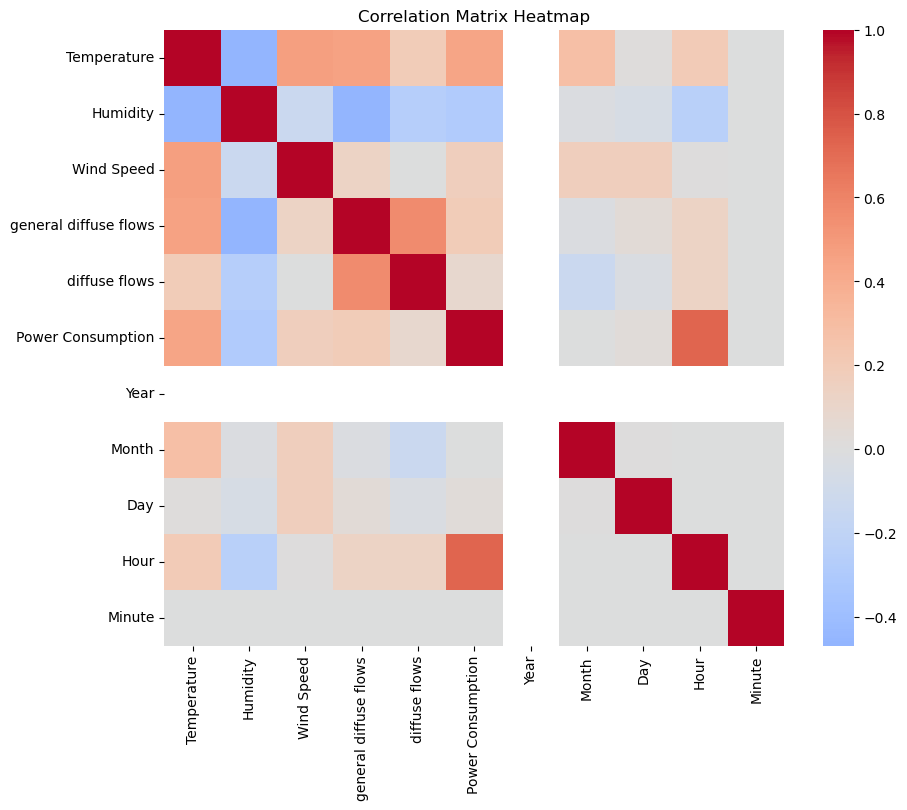

In [117]:
# Analyze and visualize the Multicollinearity in dataset (find correlations between the variables)
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr()
print(corr_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()

**explanation**
- visualizing the correlation matrix to see how features correlate with each other
- if 2 features correlate too much, it may need to be removed
- heatmap matches the results of `df.corr()` from before

In [118]:
from sklearn.linear_model import LinearRegression
# Implement simple linear regressions to predict power consumption of the town, 
#provide Results, Accuracy Score of Prediction and Visualization.

#train model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [119]:
# make predictions
y_pred = model.predict(X_test)

# Quick look at predicted vs actual
comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(comparison.head())

            Actual     Predicted
15506  32985.14532  35719.881032
51943  34737.64259  36471.627458
212    27894.68354  31961.148903
11210  42476.93617  38726.866735
16307  21341.14101  27450.670348


**explanation**
- making the predictions
- printed comparisons of actual vs predicted

In [120]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# evaluate model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")   
print(f"R²:   {r2:.2f}")     

RMSE: 4861.67
R²:   0.53


**explanation**
- RMSE → the error (distance between the predicted values and the actual values.)
- R² score → how well model explains data (closer to 1 = better)

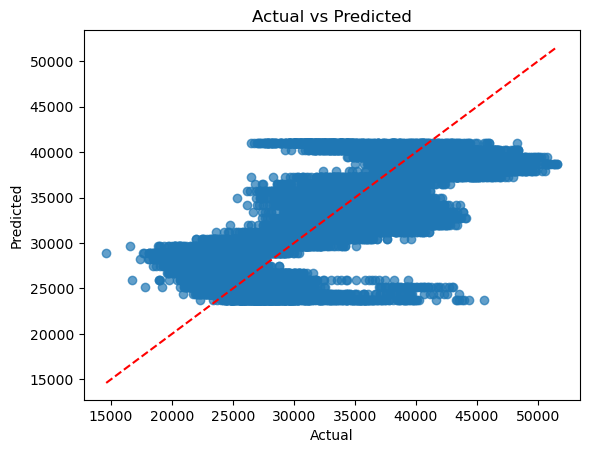

In [121]:
# plot results
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")  
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


**explanation**
- plotted predicted vs actual
- closer to the dotted line means better prediction

In [122]:
from sklearn.preprocessing import PolynomialFeatures
# Implement polynomial linear regressions, provide Results, Accuracy Score of Prediction and Visualization.
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

#train
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [123]:
#make prediction
y_pred_poly = poly_model.predict(X_test_poly)

**explanation**
- next, I implemented polynomial linear regressions.
- still using Hour as my feature. 1 feature, nonlinear relationship

In [125]:
#evaluate
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)

print(f"RMSE: {rmse:.2f}")  
print(f"R²:   {r2:.2f}")    

RMSE: 4216.03
R²:   0.65


**explanation**

Notes from ChatGPT: 
- RMSE → the error (distance between the predicted values and the actual values.)
- R² score → how well model explains data (closer to 1 = better)


Results:
- better score than simple linear when compared.
- smaller error, and $R^2$ is closer to 1

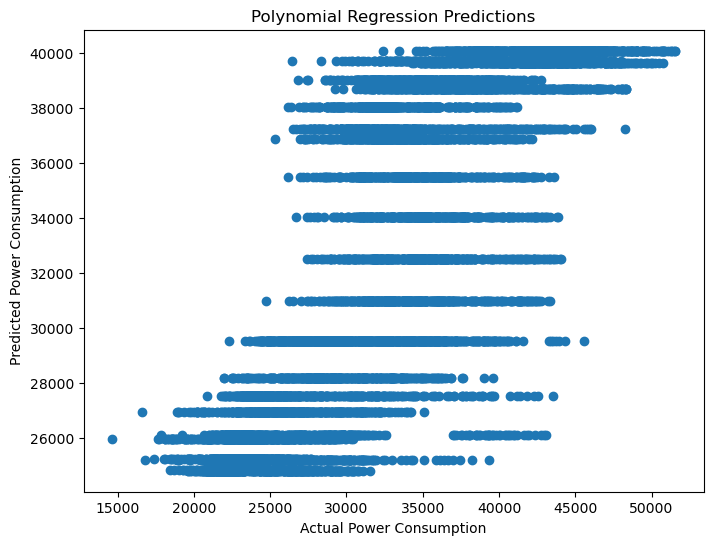

In [91]:
# visual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_poly)
plt.xlabel("Actual Power Consumption")
plt.ylabel("Predicted Power Consumption")
plt.title("Polynomial Regression Predictions")
plt.show()

**explanation**
- plot for polynomial linear regression
- each dot is a datapoint
- a diagonal line would be perfect if prediction is 100%
- prediction is horizontal and grouped by hours since we are using hours as features
- The plot definitely shows that there are still errors and the model is not completely accurate.

In [126]:
# reassign X for multiple linear regression, removing year
X = df[[
"Temperature",
"Humidity",
"Wind Speed",
"general diffuse flows",
"diffuse flows",
"Hour",
"Month",
"Day"
]]
y = df["Power Consumption"]

# Split into training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**explanastion**
- moving onto multiple linear regression, now I reassigned X since we can use all the features
- Power consumption remains as Y as our target

In [127]:
# multiple linear regression
mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [128]:
# make predictions
y_pred_mlr = mlr_model.predict(X_test)

In [129]:
#evaluate
mse = mean_squared_error(y_test, y_pred_mlr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_mlr)

print(f"RMSE: {rmse:.2f}")  
print(f"R²:   {r2:.2f}")   

RMSE: 4236.83
R²:   0.64


**explanation**
- made prediction with multiple features
- evaluated and the results is slightly worse than polynomial regression
- This shows that a nonlinear model fares a better prediction. Polynomial model is curved and better represents the pattern of power consumption

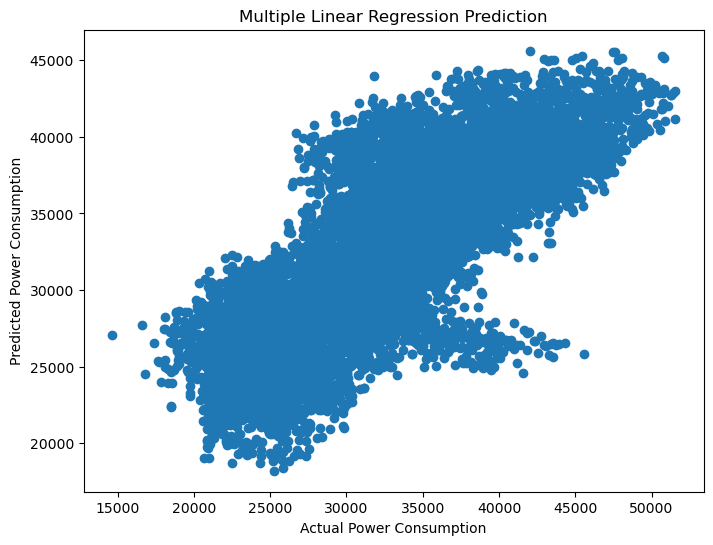

In [101]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_mlr)
plt.xlabel("Actual Power Consumption")
plt.ylabel("Predicted Power Consumption")
plt.title("Multiple Linear Regression Prediction")
plt.show()

**explanation**
- same idea applies for this plot, a diagonal line would mean perfect prediction
- as shown, the prediction is fairly centered, you can see a diagonal shape, but not perfect.

**Reference list:**
OpenAI. (2026). ChatGPT (5.2) [Large language model]. https://chat.openai.com/